In [2]:
# Install required libraries

!pip install numpy pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Set random seed
np.random.seed(42)

# Number of houses
n = 1000

# Generate synthetic features
area = np.random.randint(500, 4000, n)

bedrooms = np.random.randint(1, 6, n)

bathrooms = np.random.randint(1, 4, n)

age = np.random.randint(0, 30, n)

parking = np.random.randint(0, 3, n)

locations = ['Urban', 'Suburban', 'Rural']
location = np.random.choice(locations, n)

furnishing = ['Furnished', 'Semi-Furnished', 'Unfurnished']
furnish = np.random.choice(furnishing, n)

# Price formula (synthetic logic)
price = (
    area * 3000
    + bedrooms * 50000
    + bathrooms * 30000
    - age * 2000
    + parking * 20000
    + np.where(location == 'Urban', 200000, 0)
    + np.where(location == 'Suburban', 100000, 0)
    + np.where(furnish == 'Furnished', 80000, 0)
    + np.random.randint(-50000, 50000, n)
)

# Create DataFrame
df = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age': age,
    'parking': parking,
    'location': location,
    'furnishing': furnish,
    'price': price
})

# Save dataset
df.to_csv("housing_data.csv", index=False)

df.head()

,area,bedrooms,bathrooms,age,parking,location,furnishing,price
0,3674,2,1,27,0,Rural,Unfurnished,11109084
1,1360,1,2,25,1,Suburban,Furnished,4334237
2,1794,2,1,10,0,Rural,Furnished,5587497
3,1630,1,1,8,0,Suburban,Unfurnished,5004178
4,1595,4,2,6,0,Rural,Furnished,5149006


In [5]:
df = pd.read_csv("housing_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1000, 8)


,area,bedrooms,bathrooms,age,parking,location,furnishing,price
0,3674,2,1,27,0,Rural,Unfurnished,11109084
1,1360,1,2,25,1,Suburban,Furnished,4334237
2,1794,2,1,10,0,Rural,Furnished,5587497
3,1630,1,1,8,0,Suburban,Unfurnished,5004178
4,1595,4,2,6,0,Rural,Furnished,5149006


In [6]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("After cleaning:", df.shape)

area          0
bedrooms      0
bathrooms     0
age           0
parking       0
location      0
furnishing    0
price         0
dtype: int64
After cleaning: (1000, 8)


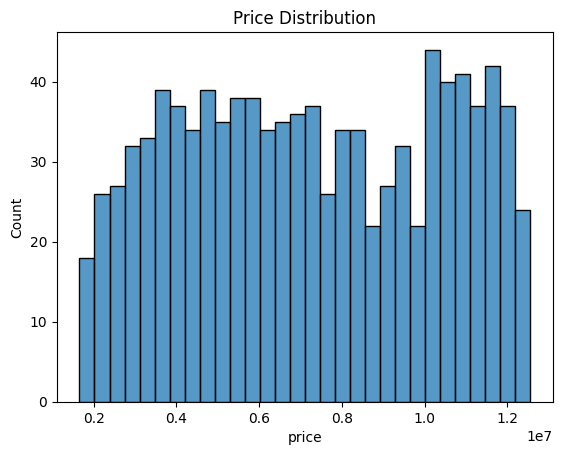

In [7]:
plt.figure()

sns.histplot(df['price'], bins=30)

plt.title("Price Distribution")

plt.savefig("price_distribution.png")

plt.show()

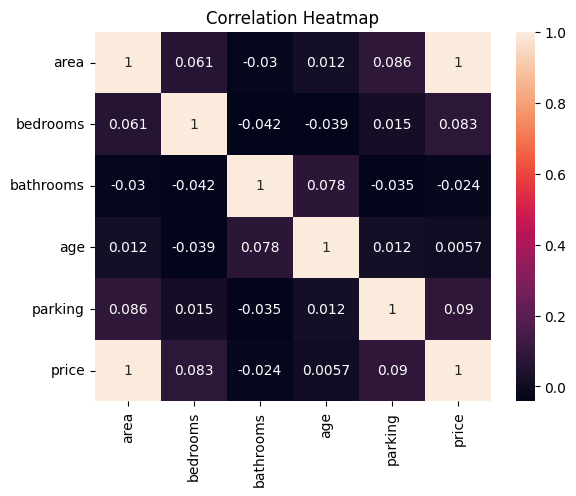

In [8]:
plt.figure()

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png")

plt.show()

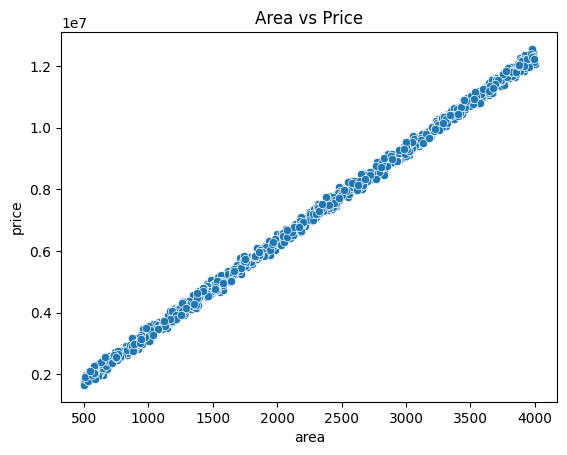

In [9]:
plt.figure()

sns.scatterplot(
    x=df['area'],
    y=df['price']
)

plt.title("Area vs Price")

plt.savefig("area_vs_price.png")

plt.show()

In [10]:
# One-hot encoding

df_encoded = pd.get_dummies(
    df,
    columns=['location', 'furnishing'],
    drop_first=True
)

df_encoded.head()

,area,bedrooms,bathrooms,age,parking,price,location_Suburban,location_Urban,furnishing_Semi-Furnished,furnishing_Unfurnished
0,3674,2,1,27,0,11109084,False,False,False,True
1,1360,1,2,25,1,4334237,True,False,False,False
2,1794,2,1,10,0,5587497,False,False,False,False
3,1630,1,1,8,0,5004178,True,False,False,True
4,1595,4,2,6,0,5149006,False,False,False,False


In [11]:
X = df_encoded.drop('price', axis=1)

y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 9)
Testing Data: (200, 9)


In [12]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_test)

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [14]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, r2

In [15]:
lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    linear_pred
)

print("Linear Regression Results:")

print("MAE:", lr_mae)

print("RMSE:", lr_rmse)

print("R2 Score:", lr_r2)

Linear Regression Results:
MAE: 25917.50993130596
RMSE: 29768.9185922273
R2 Score: 0.9999050673950075


In [16]:
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)

print("Random Forest Results:")

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

print("R2 Score:", rf_r2)

Random Forest Results:
MAE: 89712.15705
RMSE: 110286.72729789236
R2 Score: 0.9986970259082903


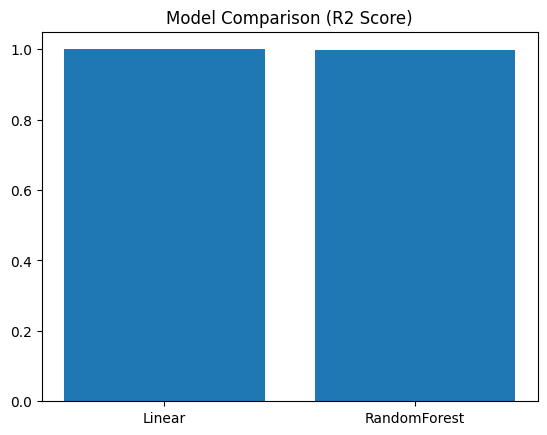

In [17]:
models = ['Linear', 'RandomForest']

r2_scores = [lr_r2, rf_r2]

plt.figure()

plt.bar(
    models,
    r2_scores
)

plt.title("Model Comparison (R2 Score)")

plt.savefig("model_comparison.png")

plt.show()

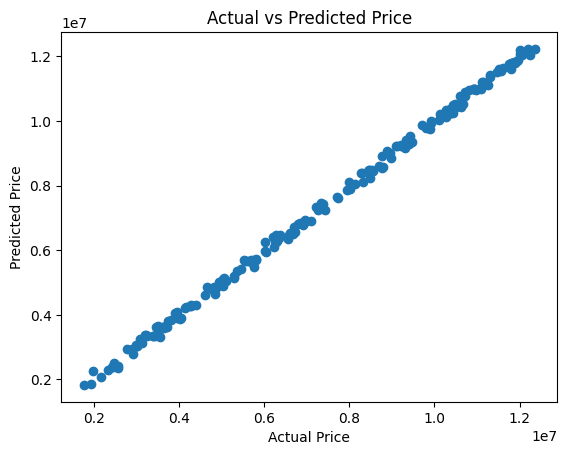

In [18]:
plt.figure()

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.savefig("actual_vs_predicted.png")

plt.show()

In [19]:
# Example new house

new_house = pd.DataFrame({

    'area': [2000],
    'bedrooms': [3],
    'bathrooms': [2],
    'age': [5],
    'parking': [1],

    'location_Suburban': [1],
    'location_Urban': [0],

    'furnishing_Semi-Furnished': [1],
    'furnishing_Unfurnished': [0]

})

predicted_price = rf_model.predict(
    new_house
)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 6334478.29


In [20]:
import pickle

# Save models

pickle.dump(
    linear_model,
    open("linear_model.pkl", "wb")
)

pickle.dump(
    rf_model,
    open("random_forest.pkl", "wb")
)

print("Models saved successfully!")

Models saved successfully!
